# 01 Rl Applications

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply RL to games, control, or recommendation
- Identify reward design and environment interfaces

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 4, lesson 03 "Reinforcement Learning: DQN and Policy Gradients" — that lesson listed games, robotics, recommendation and autonomous driving as RL's home ground; here you look at what each of those domains actually has to define — the state, the action set and the reward — before any algorithm is chosen.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 5**.

---


## Lesson Brief

This lesson shows students where reinforcement learning appears outside toy benchmarks.

The main goal is to help them recognize which real-world problems fit the RL pattern and which ones do not.

Why this matters: students should not leave the course thinking RL is only for games.

This notebook gives the application lens for the rest of Unit 5.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: controlling a fusion plasma — and the shorter list of everything else

**The yes.** Inside a tokamak, hydrogen plasma hotter than the core of the Sun is held away from the
vessel wall by magnetic fields — ITER puts the temperature fusion needs at around 150 million °C.
Nineteen magnetic control coils must have their voltages adjusted thousands of times a second, and
the plasma's shape is the thing being controlled. Degrave et al. ("Magnetic control of tokamak
plasmas through deep reinforcement learning", *Nature* **602**, 414–419, 16 February 2022) trained a
controller in simulation and then ran it on the **TCV tokamak at EPFL** in Switzerland — the first
time reinforcement learning has performed feedback control on a real tokamak. It produced and held plasma
shapes that would each have needed a separately engineered controller before.

Look at why RL fits there, because the checklist you are about to print is testing for exactly these
properties: the decision is *sequential* (the coil setting now determines the plasma you must control
next), the *actions change the state*, feedback is delayed and physical, and a high-fidelity simulator
exists so exploration is affordable.

**The comparable cases — all of them already in this course.** By the end of Unit 5 you will have met
essentially every RL system that is genuinely deployed and publicly documented:

| System | What it does | Where you met it |
|---|---|---|
| Loon flight controller | station-keeps a stratospheric balloon | Unit 1, lesson 01; Unit 3, lesson 01 |
| ACAS X | aircraft collision-avoidance logic | Unit 1, lesson 03 |
| DiDi order dispatch | assigns drivers to ride requests | Unit 2, lesson 03 |
| YouTube REINFORCE recommender | selects candidate videos | Unit 3, lesson 02 |
| InstructGPT / RLHF | aligns a language model to human preferences | Unit 3, lesson 04 |
| MuZero-RC | picks VP9 encoding parameters on YouTube | Unit 5, lesson 06 |
| TCV plasma control | shapes a fusion plasma | this lesson |

That table is short on purpose. It is not a complete list — but it is not far off, and the gap
between it and the volume of published RL research is the point. RL's deployed footprint is much
smaller than its research footprint, and knowing that is part of being useful to a client.

**What goes wrong without this.** Skip the framing step and you will spend three months building an
RL system for a problem that was a forecasting problem, a bandit problem or a linear program. The
checklist below is cheap; the three months are not.


## Recommended YouTube Video

To reinforce this lesson, watch **Nicholas Renotte - "Reinforcement Learning in 3 Hours | Full Course using Python"**:
[Watch on YouTube](https://www.youtube.com/watch?v=Mut_u40Sqz4)

Suggested focus: the opening application overview before the coding sections.

Why this pick:
- practical explanation of where RL is actually used.
- Connects theory to games, robotics, trading, and control tasks.
- Good for widening student intuition beyond benchmark environments.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Application lens: translating a real task into RL.
- Objective: what success really means.
- Constraint: a real-world limit.
- Deployment gap: toy example versus real system.
- Reward misspecification: when the designed reward does not match the true goal.

### Quick Check
- How do states, actions, and rewards map to the real problem?
- Why is reward design harder in applications?
- What makes an application realistic?
- What can go wrong even if the agent optimizes the reward successfully?

### Common Mistakes
- Choosing an algorithm before formulating the problem.
- Ignoring constraints.
- Optimizing a proxy that is not the real goal.
- Forgetting that a system can maximize reward and still behave badly in practice.


## Big Idea

By Unit 5, the question is no longer only *how an RL algorithm works*.

Now the question becomes:

- where is RL actually useful?
- how do we formulate real applications?
- what makes deployment difficult in practice?

## Application Framing Before Algorithm Choice

One of the biggest mistakes in advanced RL is asking:

`Which algorithm should I use?`

before asking:

`Is this really an RL problem, and how should I formulate it?`

### The right order

1. define the state
2. define the actions
3. define the reward
4. identify constraints and safety risks
5. only then discuss algorithms

### Why this matters

In real systems, poor formulation can ruin the project even if the learning algorithm is mathematically correct.

A badly chosen reward can produce harmful behavior, and a missing constraint can make deployment unsafe.

### Teaching takeaway

Unit 5 is not only about seeing more examples.
It is about learning how to think like a designer of RL systems, not only a user of RL algorithms.

## Application Lens

For each application, ask five questions:

1. What is the state?
2. What actions are available?
3. What reward is optimized?
4. What makes the environment difficult?
5. What safety or ethical risks appear?

### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Save a value in a name so the next lines can read it.
applications = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "games": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "state": "board position or observation frame",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "action": "move or control command",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "reward": "score, win signal, survival",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "challenge": "long horizons and sparse rewards",
    # Execute: },
    },
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "robotics": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "state": "joint positions, velocities, sensor readings",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "action": "motor torques or control commands",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "reward": "stability, speed, task completion",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "challenge": "safety and sim-to-real transfer",
    # Execute: },
    },
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "recommendation": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "state": "user context and interaction history",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "action": "item or content recommendation",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "reward": "click, watch time, conversion, retention",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "challenge": "delayed rewards and user feedback loops",
    # Execute: },
    },
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "resource optimization": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "state": "current demand, supply, system load",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "action": "allocation or scheduling decision",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "reward": "efficiency, cost reduction, throughput",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "challenge": "constraints and changing conditions",
    # Execute: },
    },
# Part of a dict/set literal layout (syntax grouping).
}

# Start a loop: repeat the indented block once per item in the sequence.
for name, details in applications.items():
    # Show text or numbers in the cell output area under the code.
    print(f"\nApplication: {name}")
    # Start a loop: repeat the indented block once per item in the sequence.
    for key, value in details.items():
        # Show text or numbers in the cell output area under the code.
        print(f"  {key.title()}: {value}")



Application: games
  State: board position or observation frame
  Action: move or control command
  Reward: score, win signal, survival
  Challenge: long horizons and sparse rewards

Application: robotics
  State: joint positions, velocities, sensor readings
  Action: motor torques or control commands
  Reward: stability, speed, task completion
  Challenge: safety and sim-to-real transfer

Application: recommendation
  State: user context and interaction history
  Action: item or content recommendation
  Reward: click, watch time, conversion, retention
  Challenge: delayed rewards and user feedback loops

Application: resource optimization
  State: current demand, supply, system load
  Action: allocation or scheduling decision
  Reward: efficiency, cost reduction, throughput
  Challenge: constraints and changing conditions


## Which applications fit RL best?

RL is strongest when:

- decisions are sequential
- actions change future states
- feedback arrives over time
- a fixed supervised label is not enough

RL is weaker when the problem is one-shot, fully labeled, or unsafe to explore directly.

### Scoring this without pretending to measure it

The next cell turns those bullets into an explicit **checklist**, then counts the boxes. The
number it prints is therefore a *derived* score, not a measurement and not a benchmark result:
it is exactly as good as the yes/no judgements written in the code, and you can disagree with
any of them by editing one line and re-running.

Beware of tables of "suitability scores" that do not show where the numbers came from —
including this one, if it had not shown you.

### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# WHAT: score domains against an explicit checklist instead of quoting invented numbers.
# WHY: a bare "suitability = 4" looks like a measurement and is not one. Here the score is
#      COUNTED from four stated yes/no judgements, so a student can audit or change any of them.

# The four questions come straight from the markdown above. True = the property holds.
CRITERIA = ["sequential decisions", "actions change future state",
            "feedback is delayed", "exploration is affordable"]

domain_checklist = {
    "games":                       [True,  True,  True,  True],
    "robotics":                    [True,  True,  True,  False],   # unsafe exploration on hardware
    "recommendation":              [True,  True,  True,  False],   # experiments run on real people
    "resource optimization":       [True,  True,  True,  True],
    "static image classification": [False, False, False, True],    # one shot, fully labelled
}

print("RL-suitability checklist (a teaching rubric, NOT a benchmark measurement)")
print("=" * 78)
print(f"  {'domain':<30}" + "".join(f"{name[:11]:>13}" for name in CRITERIA) + f"{'score':>8}")
for domain, answers in domain_checklist.items():
    marks = "".join(f"{('yes' if flag else 'no'):>13}" for flag in answers)
    print(f"  {domain:<30}{marks}{sum(answers):>8}/4")

print("\nHow to read this table:")
print("  - The score is the COUNT of 'yes' answers on that row. Nothing was measured.")
print("  - Every 'no' is a judgement you are allowed to argue with. Robotics scores lower here")
print("    only because exploring on real hardware can break it - in simulation that flips.")
print("  - Static image classification scores 1/4 not because it is a weak task, but because")
print("    it is not a SEQUENTIAL one. Supervised learning is the right tool for it.")


RL-suitability checklist (a teaching rubric, NOT a benchmark measurement)
  domain                          sequential   actions cha  feedback is  exploration   score
  games                                   yes          yes          yes          yes       4/4
  robotics                                yes          yes          yes           no       3/4
  recommendation                          yes          yes          yes           no       3/4
  resource optimization                   yes          yes          yes          yes       4/4
  static image classification              no           no           no          yes       1/4

How to read this table:
  - The score is the COUNT of 'yes' answers on that row. Nothing was measured.
  - Every 'no' is a judgement you are allowed to argue with. Robotics scores lower here
    only because exploring on real hardware can break it - in simulation that flips.
  - Static image classification scores 1/4 not because it is a weak task, but bec

## Common deployment risks

Before deploying RL in the real world, check for:

- reward hacking
- unsafe exploration
- unfair or manipulative behavior
- poor robustness under shift
- misleading evaluation metrics

## Worked Comparison

The short case study below is not about mastering one algorithm.
It is about seeing how the same RL thinking pattern appears across domains.

## Worked Example: Comparing Application Formulations

Below we compare three application domains at the formulation level:

- recommendation
- robotics
- inventory/resource optimization

The goal is to understand the *problem framing* before choosing the algorithm.

### Step Guide

**What this cell does:** Summarize or compare results (policies, returns, tables) for the lesson goal.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Tables, arrays, or comparison prints showing which policy or method wins.

**If you feel lost:** If output is empty, run the previous cells that define the data this cell consumes.


In [3]:
# Final computation: this cell usually summarizes the lesson, evaluates the result, or compares strategies.
# Pause here and ask what the numbers or tables say about the decision-making process.

# Save a value in a name so the next lines can read it.
application_table = [
    # Execute: ["Recommendation", "user profile + history", "recommend item", "engagement / retention", " …
    ["Recommendation", "user profile + history", "recommend item", "engagement / retention", "filter bubbles"],
    # Execute: ["Robotics", "robot state + sensors", "motor command", "task success + stability", "unsafe …
    ["Robotics", "robot state + sensors", "motor command", "task success + stability", "unsafe exploration"],
    # Execute: ["Inventory", "stock + demand signal", "reorder decision", "profit - cost - shortage", "re …
    ["Inventory", "stock + demand signal", "reorder decision", "profit - cost - shortage", "reward misspecification"],
# Execute: ]
]

# Save a value in a name so the next lines can read it.
headers = ["Domain", "State", "Action", "Reward", "Risk"]
# Show text or numbers in the cell output area under the code.
print(" | ".join(headers))
# Show text or numbers in the cell output area under the code.
print("-" * 120)
# Start a loop: repeat the indented block once per item in the sequence.
for row in application_table:
    # Show text or numbers in the cell output area under the code.
    print(" | ".join(row))

# Show text or numbers in the cell output area under the code.
print("\nDiscussion prompt:")
# Show text or numbers in the cell output area under the code.
print("Notice that the algorithm is not the first design decision.")
# Show text or numbers in the cell output area under the code.
print("The first decision is how to represent the sequential decision problem well.")


Domain | State | Action | Reward | Risk
------------------------------------------------------------------------------------------------------------------------
Recommendation | user profile + history | recommend item | engagement / retention | filter bubbles
Robotics | robot state + sensors | motor command | task success + stability | unsafe exploration
Inventory | stock + demand signal | reorder decision | profit - cost - shortage | reward misspecification

Discussion prompt:
Notice that the algorithm is not the first design decision.
The first decision is how to represent the sequential decision problem well.


## 💬 Discuss

The printed checklist scores **games 4/4, resource optimization 4/4, robotics 3/4, recommendation
3/4, static image classification 1/4** — and the notebook says outright that nothing was measured and
every "no" is arguable. Argue them.

1. Robotics scores 3/4 only because exploring on real hardware can destroy it — and the notebook
   notes that in simulation the answer flips. The tokamak case *did* explore, in a simulator, then ran
   on a €100m machine. What has to be true about your simulator before that plan is responsible? Name
   the specific check you would run first.
2. Recommendation scores 3/4. But a recommender's actions change the user — what they watch, what
   they are shown next, eventually what they want. Is that a point in favour of RL (it is genuinely
   sequential) or the strongest argument against deploying it (you are optimising a person)? Take a
   side and defend it against the other.
3. Pick a real problem from a Saudi organisation you know — Hajj crowd flow, a hospital's operating
   theatre schedule, a utility's load shifting, a delivery fleet. Score it on the four criteria
   yourself and then answer the harder question: what would you build *instead* of RL, and what
   evidence would make you change your mind?


## Summary

This notebook is about **application thinking**.

### Main takeaways

- RL fits problems with sequential decisions and delayed consequences.
- The first design work is defining state, action, reward, and evaluation.
- Deployment risks matter as much as benchmark performance.
- Real applications often require safety, fairness, and robustness thinking before deployment.

### Next step

Continue to the later Unit 5 notebooks to study multi-agent RL, hierarchical RL,
and model-based RL as extensions of this application lens.

In [4]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
2. Silver, D., Huang, A., Maddison, C. J. et al. (2016). *Mastering the game of Go with deep neural networks and tree search* (AlphaGo). Nature, 529, 484-489. <https://www.nature.com/articles/nature16961>
3. Mirhoseini, A., Goldie, A., Yazgan, M. et al. (2021). *A Graph Placement Methodology for Fast Chip Design*. Nature. <https://www.nature.com/articles/s41586-021-03544-w>
4. Ouyang, L., Wu, J., Jiang, X. et al. (2022). *Training Language Models to Follow Instructions with Human Feedback* (InstructGPT — RLHF fine-tuning with PPO). NeurIPS. <https://arxiv.org/abs/2203.02155>
5. Luo, X., Zhang, Y., He, Z. et al. (2025). *Agent Lightning: Train ANY AI Agents with Reinforcement Learning* — attaching an RL trainer to an agent that already exists. arXiv:2508.03680. <https://arxiv.org/abs/2508.03680>
6. Huang, C., Wang, Z., Han, R. et al. (2026). *EnvHarness: Awakening Static Worlds for Agent Learning* — turning static software into resettable, scorable RL environments. arXiv:2608.19880. <https://arxiv.org/abs/2608.19880>
"""))

## 📚 References

1. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
2. Silver, D., Huang, A., Maddison, C. J. et al. (2016). *Mastering the game of Go with deep neural networks and tree search* (AlphaGo). Nature, 529, 484-489. <https://www.nature.com/articles/nature16961>
3. Mirhoseini, A., Goldie, A., Yazgan, M. et al. (2021). *A Graph Placement Methodology for Fast Chip Design*. Nature. <https://www.nature.com/articles/s41586-021-03544-w>
4. Ouyang, L., Wu, J., Jiang, X. et al. (2022). *Training Language Models to Follow Instructions with Human Feedback* (InstructGPT — RLHF fine-tuning with PPO). NeurIPS. <https://arxiv.org/abs/2203.02155>
5. Luo, X., Zhang, Y., He, Z. et al. (2025). *Agent Lightning: Train ANY AI Agents with Reinforcement Learning* — attaching an RL trainer to an agent that already exists. arXiv:2508.03680. <https://arxiv.org/abs/2508.03680>
6. Huang, C., Wang, Z., Han, R. et al. (2026). *EnvHarness: Awakening Static Worlds for Agent Learning* — turning static software into resettable, scorable RL environments. arXiv:2608.19880. <https://arxiv.org/abs/2608.19880>


### Step Guide

**What this cell does:** Draws the RL-suitability checklist you printed earlier as a grid, so the
one row that does not belong is visible at a glance.

**How to read it (weak Python OK):** Nothing new is decided here. The cell reads the same
`domain_checklist` dictionary you can scroll up and read yourself, and paints one square per
yes/no answer. Green means the property holds, grey means it does not.

**What to expect in the output:** A 5-row by 4-column grid of yes/no squares, each row labelled
with its domain and its counted score out of 4.

**If you feel lost:** Re-run the checklist cell above so `domain_checklist` and `CRITERIA` exist,
then run this cell again.

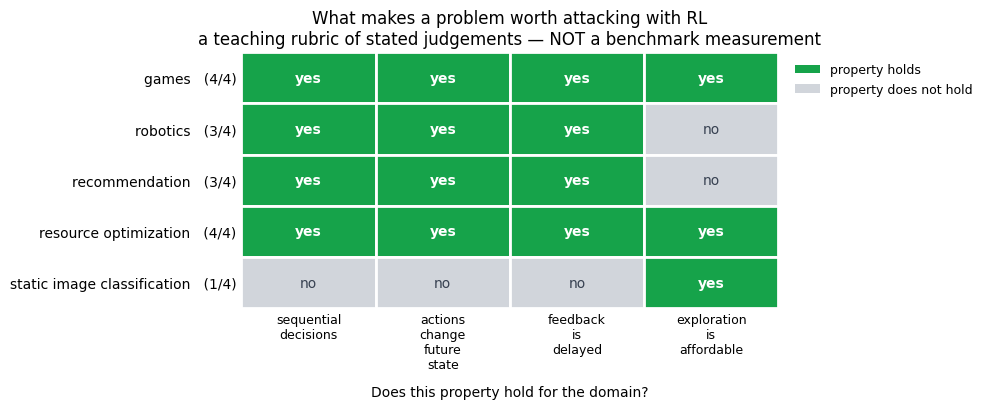

Lowest score on the rubric: 'static image classification' at 1/4.
It fails on: sequential decisions, actions change future state, feedback is delayed.
Those three failures are the same failure said three ways: the problem is not sequential.
That is a reason to reach for supervised learning, not a reason to call the task easy.


In [5]:
# ONE honest figure for this lesson: the RL-suitability checklist, drawn instead of printed.
# WHY a grid of yes/no squares and NOT a bar chart of "suitability scores": the score is a COUNT
# of four stated judgements, so showing only the total would hide the judgements and make a
# rubric look like a measurement. Drawing every answer keeps it auditable - a student who
# disagrees with one square can point at it.
# NOTE: these are our stated opinions about each domain, not benchmark results. The figure says
# so in its own subtitle, because a chart gets screenshotted away from the text around it.

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

YES_COLOUR, NO_COLOUR = "#16a34a", "#d1d5db"     # green = property holds, grey = it does not

domains = list(domain_checklist.keys())
answers_grid = [domain_checklist[d] for d in domains]

fig, ax = plt.subplots(figsize=(10, 4.2))
for row, flags in enumerate(answers_grid):
    for col, holds in enumerate(flags):
        # One square per (domain, criterion). Colour AND the word carry the same answer, so the
        # figure still reads correctly in greyscale or for a colour-blind student.
        ax.add_patch(plt.Rectangle((col, row), 1, 1,
                                   facecolor=YES_COLOUR if holds else NO_COLOUR,
                                   edgecolor="white", linewidth=2))
        ax.text(col + 0.5, row + 0.5, "yes" if holds else "no",
                ha="center", va="center", fontsize=10,
                color="white" if holds else "#374151",
                fontweight="bold" if holds else "normal")

ax.set_xlim(0, len(CRITERIA)); ax.set_ylim(0, len(domains))
ax.invert_yaxis()                                  # first domain at the top, reading order

# Real tick labels on both axes: the four questions, and the domains with their counted score.
ax.set_xticks([c + 0.5 for c in range(len(CRITERIA))])
ax.set_xticklabels([c.replace(" ", "\n") for c in CRITERIA], fontsize=9)
ax.set_yticks([r + 0.5 for r in range(len(domains))])
ax.set_yticklabels([f"{d}   ({sum(domain_checklist[d])}/4)" for d in domains], fontsize=10)
ax.tick_params(length=0)
for side in ax.spines.values():
    side.set_visible(False)

ax.set_xlabel("Does this property hold for the domain?", fontsize=10, labelpad=10)
ax.set_title("What makes a problem worth attacking with RL\n"
             "a teaching rubric of stated judgements — NOT a benchmark measurement",
             fontsize=12)
ax.legend(handles=[Patch(facecolor=YES_COLOUR, label="property holds"),
                   Patch(facecolor=NO_COLOUR, label="property does not hold")],
          loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

# Name the outlier in words, computed from the same dictionary the squares are drawn from.
scores = {d: sum(domain_checklist[d]) for d in domains}
lowest = min(scores, key=scores.get)
print(f"Lowest score on the rubric: '{lowest}' at {scores[lowest]}/4.")
print(f"It fails on: " + ", ".join(c for c, holds in zip(CRITERIA, domain_checklist[lowest])
                                   if not holds) + ".")
print("Those three failures are the same failure said three ways: the problem is not sequential.")
print("That is a reason to reach for supervised learning, not a reason to call the task easy.")

### 👁️ Read the figure

- **One square per judgement, five domains down the side and four questions across the top.**
  Green means we claim the property holds for that domain; grey means it does not. Each square
  also carries the word, so the figure survives being printed in black and white.
- **Read the rows, not the totals.** The score in each row label is nothing more than the count of
  green squares in that row — there is no hidden measurement behind it. The subtitle says so on
  the figure itself, because a chart gets screenshotted and pasted somewhere the surrounding text
  does not follow.
- **The bottom row is the one to look at.** Static image classification is grey on the first three
  questions and green only on the last. That is not three separate weaknesses; it is one — the
  problem is not sequential, so nothing an action does changes what comes next, and there is no
  delayed consequence to reason about.
- **Two rows are grey in exactly one place, and it is the same place.** Robotics and
  recommendation are grey only on "exploration is affordable", for very different reasons: one
  breaks hardware, the other experiments on real people. Same square, same colour, different
  problem — which is why you should argue with these squares rather than trust them.

**What it proves:** the lesson's opening claim, that framing comes before algorithm choice. RL
earns its place when a decision changes what you face next and the payoff arrives late. Where that
is not true — the bottom row — RL is not a stronger tool that would be overkill, it is the wrong
shape of tool, and a supervised model is the right answer.

## ⚠️ Where this breaks

**The assumption that has to hold:** the problem is genuinely sequential, exploration is affordable,
and the reward is measurable. Fail any one and RL is the wrong tool — usually an expensive one.

- **If your action does not change the state, use a bandit.** Which thumbnail, which price, which of
  three onboarding flows: these are Unit 4 problems. Bandits need far less data, have proven regret
  bounds, and are far easier to explain to a compliance officer. Reaching for a full MDP here costs
  you months and buys nothing.
- **If you are choosing a fixed allocation under known constraints, use optimisation.** Staff
  rosters, vehicle routing, portfolio weights, network flows: linear and integer programming solve
  these to *proven optimality* with solvers that have been hardened for decades. RL competes only
  when the constraints or the demand are stochastic and evolving — and even then, the honest baseline
  in your report should be the solver, not a random policy.
- **If the decision is a one-shot prediction, use supervised learning.** The checklist's 1/4 for image
  classification is not a slight. There is no sequence, so there is nothing for a value function to
  do.
- **If you cannot explore, you do not have RL — you have offline RL.** No simulator and no permission
  to experiment (healthcare, credit decisions, safety systems) puts you in the regime of Unit 2,
  lesson 04: learning from logs, where the binding constraint is evaluating the policy, not finding
  it.
- **And check the reward exists before anything else.** "Customer satisfaction" is not a reward signal
  until somebody can compute it per step from data you actually collect. If nobody can, the project's
  first deliverable is a measurement system, not an agent.


## Closing Takeaway

**Teaching takeaway:** Real RL applications begin by matching the problem structure to the right decision framework, constraints, and success metric.

**If students remember one idea:** An application is not automatically a good RL problem. Students must ask what is sequential, what is uncertain, and what feedback is available.

**Quick check before moving on:**
- Can you explain what makes a practical problem suitable for RL?
- Can you describe when a non-RL approach may actually be the better choice?

**Bridge to the next step:** The next lessons make this concrete through specific application areas such as games and resource allocation.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## 🔭 State of the field (2026)

The table above is an honest list of publicly documented, deployed RL systems, and it is short. What grew
fastest between 2023 and 2026 is one row of it, generalised: RLHF became RL on **language-model agents** —
policies that read a task, call tools and return a result — and there are now frameworks whose entire purpose
is to attach an RL trainer to an agent somebody has already written (Luo et al. 2025). The binding constraint moved with the application. The scarce resource in 2026 is not the
algorithm and not the compute — it is the **environment**: a task that can be reset, stepped and scored
automatically, which is why current work is about converting static software and documents into trainable
environments at all (Huang et al. 2026).

None of that changes what this lesson asks you to do; it raises the value of doing it. Every question on the
checklist you just printed — is the decision sequential, do actions change the state, is feedback delayed, can
we afford to explore — is exactly what an engineer asks before turning a business workflow into an agent
environment, and "nobody can compute a reward per step" is still the finding that stops most projects before
they start. The application lens is the transferable skill. The list of applications is the part that dates.

- Luo, X., Zhang, Y., He, Z. et al. (2025). *Agent Lightning: Train ANY AI Agents with Reinforcement Learning*. arXiv:2508.03680. <https://arxiv.org/abs/2508.03680>
- Huang, C., Wang, Z., Han, R. et al. (2026). *EnvHarness: Awakening Static Worlds for Agent Learning*. arXiv:2608.19880. <https://arxiv.org/abs/2608.19880>

*Context, not curriculum. The examinable content of this lesson is unchanged; this box says where the field went next.*

## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=6 | term=True | trunc=False


objc[67252]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113ac0138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x113fbc9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[67252]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113ac0188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x113fbca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[67252]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113abfc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x113fbca68). T

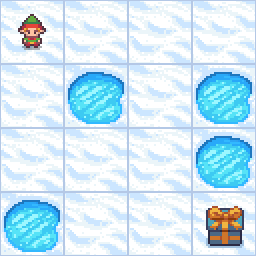

In [6]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
